### Итоговый проект по дисциплине «Внедрение моделей машинного обучения»

## Название проекта

Разработка и внедрение сервиса прогнозирования дефолта по кредитным картам с контейнеризацией и A/B-тестированием

## Описание проекта

Цель проекта: разработать и внедрить в production-like-среду сервис машинного обучения для прогнозирования дефолта по кредитным картам, который охватывает полный цикл от сохранения модели до организации A/B-тестирования.

Домен: финансы / кредитный скоринг.

Датасет: Default of Credit Card Clients Dataset с UCI Machine Learning Repository.

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset



- Описание: датасет содержит информацию о клиентах кредитной карты на Тайване с таргетом default.payment.next.month (дефолт в следующем месяце). Включает демографические данные, историю платежей, суммы счетов.
- Актуальность: идеально подходит для демонстрации полного цикла внедрения ML-модели в production без излишней сложности в части построения модели.


## Задание к проекту

### Контекст

Вы — ML-инженер в технологическом отделе банка. Ваша задача — внедрить модель прогнозирования дефолта в виде масштабируемого веб-сервиса, готового к промышленной эксплуатации и тестированию новых версий.

### Требования к проекту

#### Часть 1. Подготовка модели к production и деплой

Организация кода и контроль версий (Git):
- Создайте структурированный репозиторий на GitHub (например, используя шаблон cookiecutter-data-science).
- Код должен быть хорошо организован в модули (папки src/, tests/, notebooks/, data/, models/ и так далее).

Сохранение и загрузка модели:
- Обучите простую модель бинарной классификации (LogisticRegression, RandomForestClassifier или GradientBoostingClassifier) на предоставленном датасете.
- Сохраните обученную модель с использованием pickle или joblib.
- Напишите функцию загрузки модели для инференса.

Веб-сервис на Flask:
- Реализуйте веб-сервис с двумя эндпоинтами:
- POST /predict — принимает JSON с признаками клиента, возвращает прогноз и вероятность.
- GET /health — проверяет работоспособности сервиса.
- Формат запроса/ответа должен быть чётко документирован.


Дополнительно (обзорно):
- В документации опишите, как можно преобразовать модель в формат ONNX-ML для оптимизации.
- Объясните, для чего используются uWSGI + NGINX в production-среде.
#### Часть 2. Воспроизводимость и контейнеризация

Воспроизводимость окружения:
- Создайте requirements.txt со всеми зависимостями проекта.
- Используйте virtualenv или venv для изоляции окружения.

Docker-контейнеризация:
- Напишите Dockerfile для упаковки веб-сервиса в контейнер.
- Соберите Docker-образ и протестируйте его локально.
- Загрузите образ в Docker Hub (публичный).

Создание образа веб-сервиса:
- Образ должен включать модель, код сервиса и все зависимости.
- Контейнер должен запускать веб-сервис на определённом порту (например, 5000).

#### Часть 3. Сервисная архитектура и оркестрация

Архитектура сервиса (концепт):
- Монолит vs микросервисы.
- В документации (ARCHITECTURE.md или в README) обоснуйте, почему в данном учебном проекте выбран монолитный или микросервисный подход для веб-сервиса.

Концепт брокеров сообщений.

- Опишите, как в гипотетическом сценарии масштабирования можно было бы использовать брокер очередей (например, RabbitMQ). Для чего он мог бы пригодиться? Пример: для асинхронной обработки батч-предсказаний или логирования. Опционально: реализуйте такой брокер сообщений в своём проекте.
- Логирование и мониторинг (обзорно).

- Укажите в коде или документации, куда и в каком формате (JSON) логируются запросы и ответы API. Упомяните, как в production-системе эти логи могли бы собираться (например, ELK-стек) для мониторинга.


Оркестрация (Docker Compose — опционально, бонус).

- Создайте базовый файл docker-compose.yml:
- который запускает ваш ML-сервис;
- (задание повышенной сложности) добавляет сервис для имитации логов (например, простой nginx) или визуализирует концепт подключения мониторинга.

Обзор инструментов MLops (концепт).

- В документации кратко опишите назначение DVC (контроль версий данных) и MLflow (отслеживание экспериментов) в контексте жизненного цикла данной модели. Реализация не требуется.
- Бизнес-метрики.

Помимо технических метрик (F1, Precision), предложите одну-две бизнес-метрики, которые важны для заказчика. Например: снижение ожидаемых финансовых потерь или увеличение доли одобренных заявок при том же уровне риска. Опишите, как их можно было бы рассчитать на основе выходов модели.


#### Часть 4. Организация A/B-тестирования

Концепция A/B-теста.

- Предложите постановку A/B-теста для сравнения двух версий модели:
- контрольной группы: текущей модели (v1);
- тестовой группы: новой модели (v2).
- Описание должно включать:
- способ разделения трафика (например, случайное распределение 50/50);
- продолжительность теста.
- Метрики и анализ:

Определите бизнес-метрики для оценки (минимум две):
- основную метрику: F1-score для класса дефолта;
- дополнительную метрику: Precision или Recall (с обоснованием выбора).


Опишите метод статистического анализа:
- какой статистический тест будет использоваться (t-test, z-test);
- как будут строиться доверительные интервалы;
- каков критерий успешности теста.


#### Часть 5. Документация и воспроизводимость

README.md:
- Описание проекта и его целей.
- Инструкция по запуску (локально и в Docker).
- Примеры запросов к API (curl-команды).
- Описание формата запросов и ответов.
- Ссылка на Docker-образ в Docker Hub.
- Структура репозитория.

- Чёткая организация файлов (отдельные папки для кода, моделей, конфигураций).


# Пример решения (ключевые компоненты)
## 1. Рекомендуемая архитектура проекта

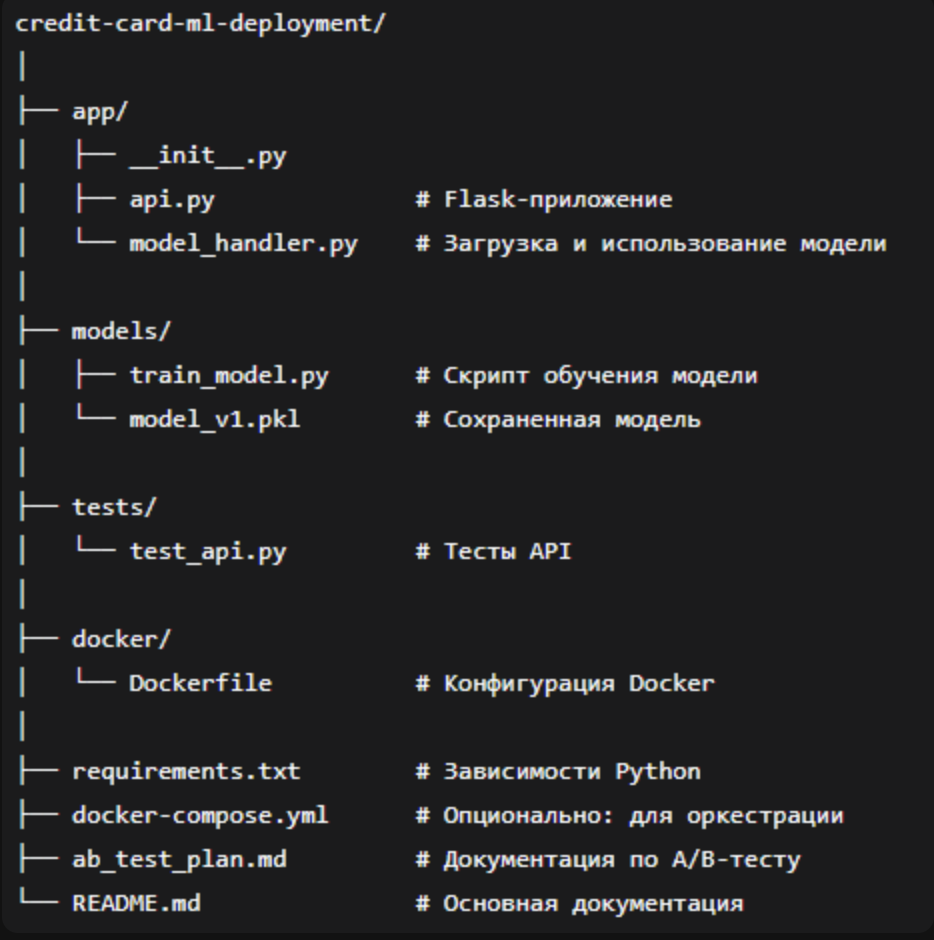

## 2. Пример Flask-приложения (app/api.py)

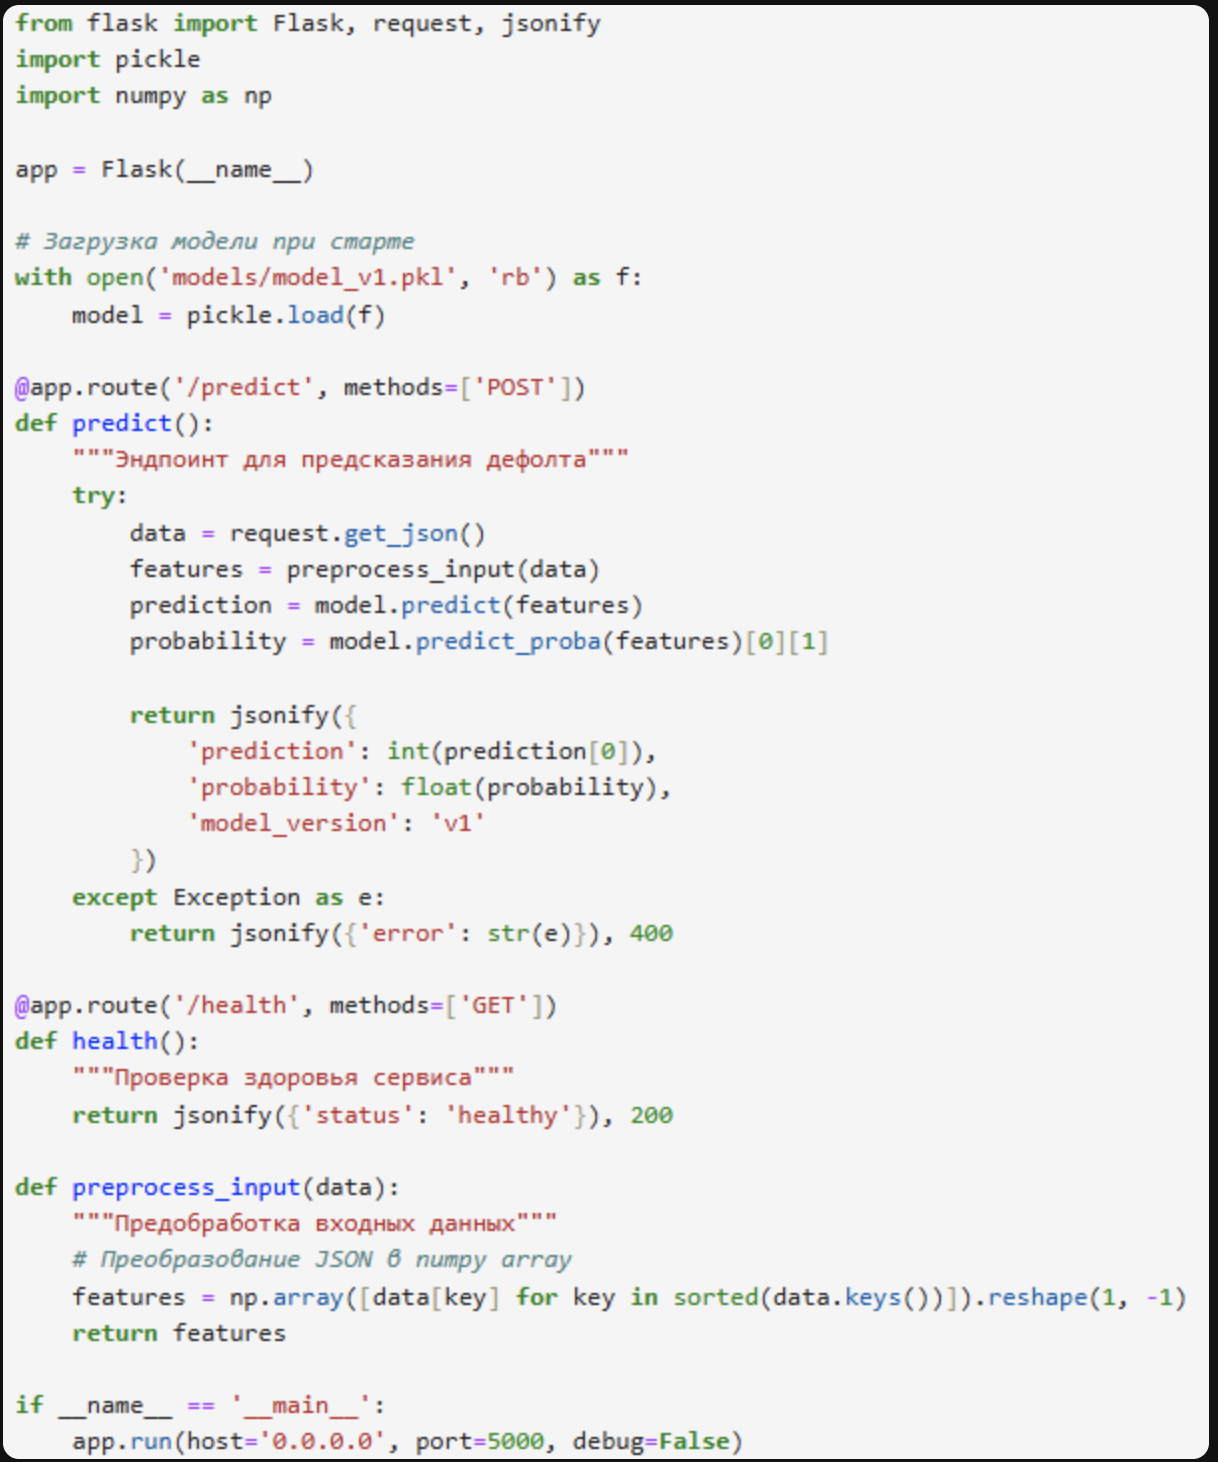

## 3. Пример Dockerfile

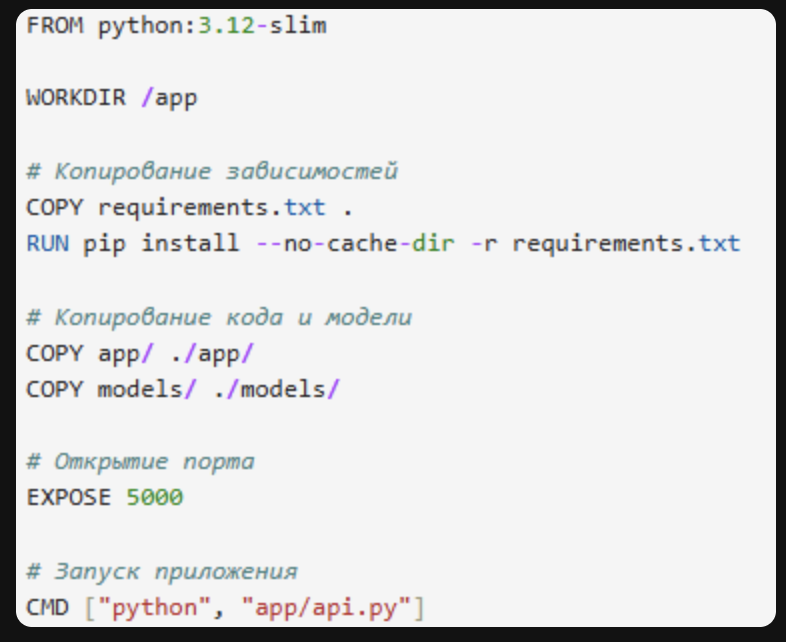

## Формат сдачи

Студент должен предоставить:

Ссылку на GitHub-репозиторий, который содержит:
- весь код проекта;
- документацию (README.md);
- файлы конфигурации.


Инструкцию по запуску в README.md, включая:
- установку зависимостей;
- запуск сервиса локально;
- сборку и запуск Docker-контейнера;
- примеры запросов к API.

Артефакты:
- файл обученной модели (.pkl или .joblib);
- equirements.txt;
- Dockerfile;
- план A/B-теста (отдельный файл или в README).

Демонстрацию работы:
- скриншоты или логи работы API;
- пример curl-запроса с выводом;
- ссылку на Docker-образ в Docker Hub.

# Ограничения и рекомендации

Сложность модели: не требуется глубокий тюнинг или сложные ансамбли. Достаточно одной правильно обученной модели.

Инфраструктура:
- Не требуется настройка NGINX/uWSGI в качестве обязательной части.
- RabbitMQ и микросервисы могут быть описаны на концептуальном уровне.
- Docker Compose — опционально для бонусных баллов.

Фокус проекта: минимально достаточный production-like pipeline — работающий сервис, готовый к развёртыванию, с продуманным планом тестирования.

Проверка: убедитесь, что проект можно полностью воспроизвести по инструкции, а Docker-образ доступен для скачивания.


Это задание охватывает все ключевые аспекты курса, делая акцент на практическом внедрении ML-моделей в production-среду с учётом реалистичных требований к промышленной эксплуатации.

In [7]:
#--------------------------------------------Import--------------------------------------------#
import pandas as pd
import numpy as np
import pickle
import math

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import load_diabetes
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.metrics import classification_report

from sklearn.ensemble import GradientBoostingClassifier

#--------------------------------------------Featur_Engineering--------------------------------------------#
class My_Featur_Engineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass 
    
    def fit(self, X, y=None):
        return self  

    def transform(self, X):
        X['utilization_1'] = X['BILL_AMT1'] / X['LIMIT_BAL']
        X['utilization_2'] = X['BILL_AMT2'] / X['LIMIT_BAL']
        X['utilization_3'] = X['BILL_AMT3'] / X['LIMIT_BAL']
        X['utilization_4'] = X['BILL_AMT4'] / X['LIMIT_BAL']
        X['utilization_5'] = X['BILL_AMT5'] / X['LIMIT_BAL']
        X['utilization_6'] = X['BILL_AMT6'] / X['LIMIT_BAL']

        #сумма платежа к прошлому счету 
        X['pay_to_bill_ratio_1'] = X['PAY_AMT1'] / (X['BILL_AMT2'] + 1)
        X['pay_to_bill_ratio_2'] = X['PAY_AMT2'] / (X['BILL_AMT3'] + 1)
        X['pay_to_bill_ratio_3'] = X['PAY_AMT3'] / (X['BILL_AMT4'] + 1)
        X['pay_to_bill_ratio_4'] = X['PAY_AMT4'] / (X['BILL_AMT5'] + 1)
        X['pay_to_bill_ratio_5'] = X['PAY_AMT5'] / (X['BILL_AMT6'] + 1)

        #прирост долга 
        X['bill_diff_1_2'] = X['BILL_AMT1'] - X['BILL_AMT2']
        X['bill_diff_2_3'] = X['BILL_AMT2'] - X['BILL_AMT3']
        X['bill_diff_3_4'] = X['BILL_AMT3'] - X['BILL_AMT4']
        X['bill_diff_4_5'] = X['BILL_AMT4'] - X['BILL_AMT5']
        X['bill_diff_5_6'] = X['BILL_AMT5'] - X['BILL_AMT6']

        # Список всех колонок со счетами
        bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

        # Средний счет и средний платеж
        X['avg_bill'] = X[bill_cols].mean(axis=1)
        X['avg_pay'] = X[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

        pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

        # Считаем количество месяцев с просрочкой
        X['months_with_delay'] = (X[pay_status_cols] > 0).sum(axis=1)

        X = X.fillna(0)
        X = X.replace([np.inf, -np.inf], 0).fillna(0)

        X = X.drop(columns=['ID'])

        return X

def load_mmodel(name):
    # Десериализуем pipeline из файла
    with open('name', 'rb') as pkl_file:
        loaded_pipe = pickle.load(pkl_file)


def dump_model(name, model):
    # Сериализуем pipeline и записываем результат в файл
    with open(name, 'wb') as output:
        pickle.dump(model, output)

        

def train_model(X, y):
    
    lo_pipe = Pipeline([  
    ('FeatureEngineering', My_Featur_Engineering()),
    ('FeatureSelection', SelectKBest(f_regression, k=5)),
    ('GradientBoostingClassifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,random_state=42))
    ])

    # Обучаем пайплайн
    lo_pipe.fit(X, y)
    
    return lo_pipe


def my_classification_report(model, X, y):
    predictions = model.predict(X)
    print("Отчет по классификации:")
    print(classification_report(y, predictions)) 


def read_df(name='UCI_Credit_Card.csv'):
    return pd.read_csv(name)


#--------------------------------------------Fit model --------------------------------------------#
def main_with_report():
    go_train = read_df()

    X = go_train.drop(columns='default.payment.next.month')
    y = go_train['default.payment.next.month']

    gv_name = 'model_v1.pkl'

    go_pipe = train_model(X, y)

    my_classification_report(go_pipe, X, y)


def main_with_dump_model():
    go_train = read_df()

    X = go_train.drop(columns='default.payment.next.month')
    y = go_train['default.payment.next.month']

    gv_name = 'model_v1.pkl'

    go_pipe = train_model(X, y)

    dump_model(gv_name,go_pipe)

In [8]:
main_with_report()

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     23364
           1       0.69      0.37      0.48      6636

    accuracy                           0.82     30000
   macro avg       0.77      0.66      0.69     30000
weighted avg       0.81      0.82      0.80     30000

